In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
dataset = pd.read_csv("insurance.csv")

In [3]:
print(dataset.head())
print(dataset.shape)
print(dataset.info())

   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520
(1338, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB
None


In [4]:
print(dataset.isnull().sum())

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


In [5]:
duplicate= dataset.duplicated().sum()
print(duplicate)

1


In [8]:
dataset[dataset.duplicated(keep=False)]

,age,sex,bmi,children,smoker,region,charges


In [6]:
dataset = dataset.drop_duplicates()

In [7]:
print(dataset.duplicated().sum())

0


In [9]:
num_cols = dataset.select_dtypes(include=np.number).columns.tolist()
cat_cols = dataset.select_dtypes(include='object').columns.tolist()

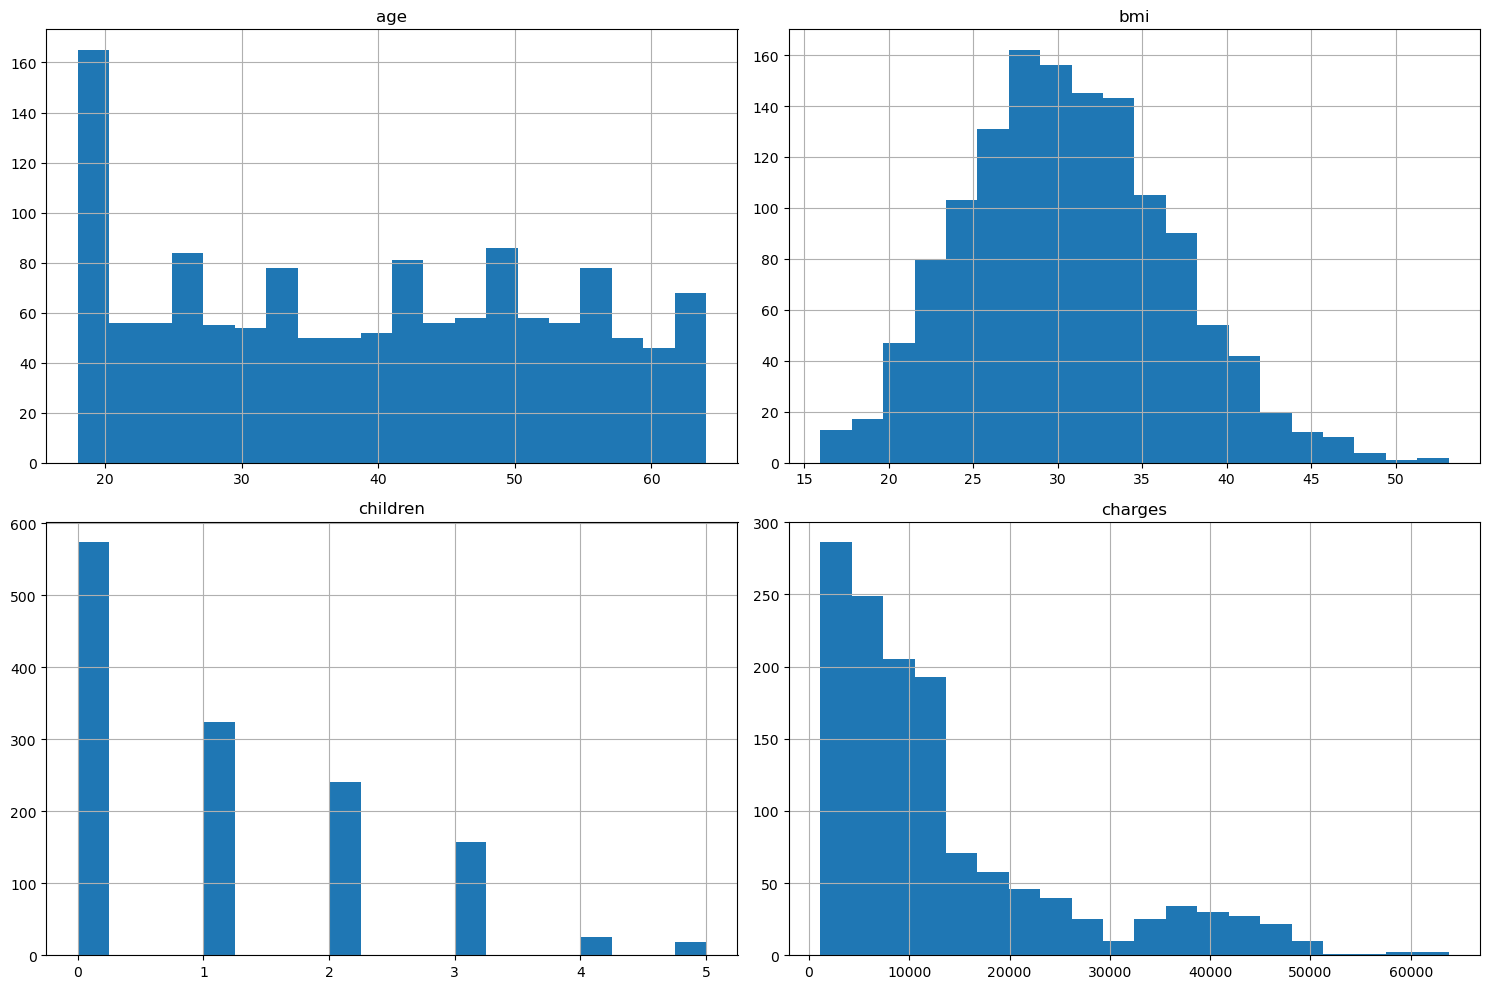

In [11]:
# Ploting to check if columns are skewed

dataset[num_cols].hist(
    figsize=(15,10),
    bins=20
)

plt.tight_layout()
plt.show()

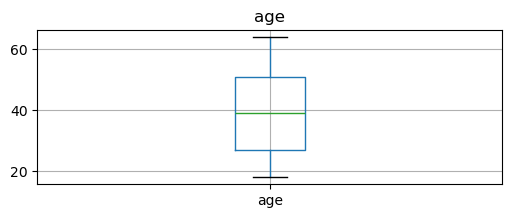

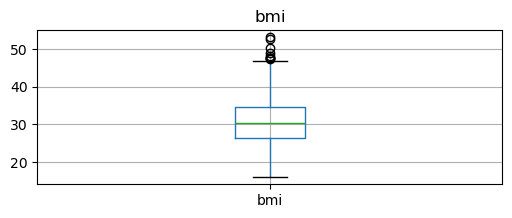

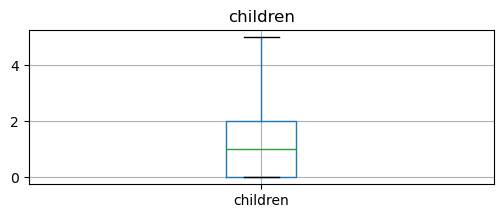

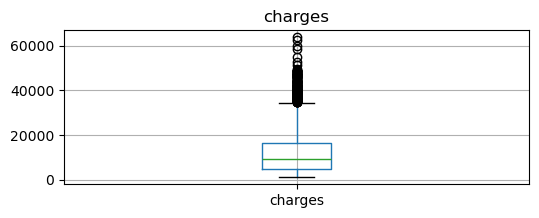

In [13]:
for col in num_cols:
    plt.figure(figsize=(6,2))
    dataset.boxplot(column=col)
    plt.title(col)
    plt.show()

In [15]:
dataset[num_cols].skew().sort_values()


age         0.054781
bmi         0.283914
children    0.937421
charges     1.515391
dtype: float64

In [16]:
for col in cat_cols:
    print("\n")
    print(dataset[col].value_counts(normalize=True)*100)



sex
male      50.486163
female    49.513837
Name: proportion, dtype: float64


smoker
no     79.506358
yes    20.493642
Name: proportion, dtype: float64


region
southeast    27.225131
southwest    24.308153
northwest    24.233358
northeast    24.233358
Name: proportion, dtype: float64


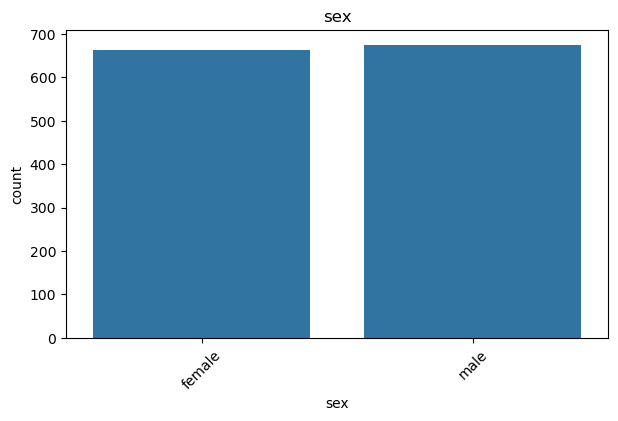

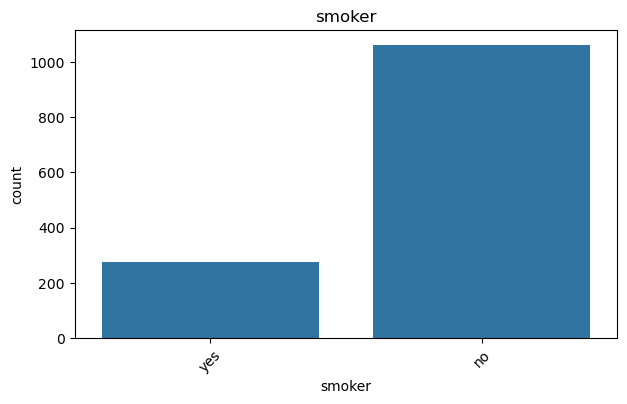

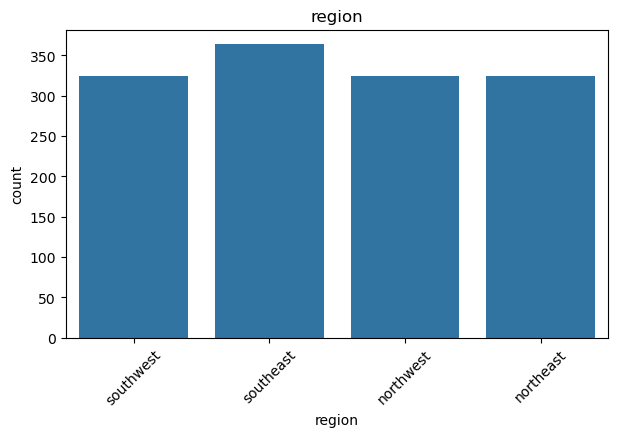

In [20]:
for col in cat_cols:
    plt.figure(figsize=(7,4))
    sns.countplot(data=dataset, x=col)
    plt.title(col)
    plt.xticks(rotation=45)
    plt.show()

In [21]:
# Binary
dataset['sex'] = dataset['sex'].map({
    'male':1,
    'female':0
})

# Binary
dataset['smoker'] = dataset['sex'].map({
    'yes':1,
    'no':0
})

In [22]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1337 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1337 non-null   int64  
 1   sex       1337 non-null   int64  
 2   bmi       1337 non-null   float64
 3   children  1337 non-null   int64  
 4   smoker    0 non-null      float64
 5   region    1337 non-null   object 
 6   charges   1337 non-null   float64
dtypes: float64(3), int64(3), object(1)
memory usage: 83.6+ KB
